### Select the time for load forecast from data_load_forecast 
Align the PV forecast time with load \
Export the load forecast csv put into emhass and run

In [1]:
import pandas as pd
column_names = ['timestamp','P_Load']
df = pd.read_csv('data_load_forecast.csv', header=None, names=column_names)
df.head()

,timestamp,P_Load
0,6/1/2025 0:00,503.406806
1,6/1/2025 0:30,502.879320
2,6/1/2025 1:00,514.847412
3,6/1/2025 1:30,476.294995
4,6/1/2025 2:00,516.189519


In [2]:
# Convert the timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Filter rows after 7/7/2025 14:00
filtered_df = df[df['timestamp'] > pd.Timestamp('2025-07-07 14:00')]

filtered_df.head()

,timestamp,P_Load
1757,2025-07-07 14:30:00,599.195355
1758,2025-07-07 15:00:00,566.888373
1759,2025-07-07 15:30:00,372.365581
1760,2025-07-07 16:00:00,490.296861
1761,2025-07-07 16:30:00,526.718972


In [3]:
#filtered_df.to_csv('filtered_data_load_forecast.csv', index=False)

### Import the emhass optimized result

In [4]:
import pandas as pd
optimal_df = pd.read_csv('PV_opt_res_latest.csv')
optimal_df.head()

,timestamp,P_PV,P_Load,P_deferrable0,P_deferrable1,P_deferrable2,P_grid_pos,P_grid_neg,P_grid,unit_load_cost,unit_prod_price,cost_profit,cost_fun_profit,optim_status
0,2025-07-14 14:30:00+08:00,3066.979501,599.195355,0.0,0.0,0.0,0.0,-2467.78410,-2467.78410,0.1419,0.1419,0.175089,0.175089,Optimal
1,2025-07-14 15:00:00+08:00,2894.649727,566.888373,0.0,0.0,0.0,0.0,-2327.76140,-2327.76140,0.1419,0.1419,0.165155,0.165155,Optimal
2,2025-07-14 15:30:00+08:00,2648.643053,372.365581,0.0,0.0,0.0,0.0,-2276.27750,-2276.27750,0.1419,0.1419,0.161502,0.161502,Optimal
3,2025-07-14 16:00:00+08:00,2324.900487,490.296861,1000.0,0.0,0.0,0.0,-834.60363,-834.60363,0.1419,0.1419,0.059215,0.059215,Optimal
4,2025-07-14 16:30:00+08:00,1939.954574,526.718972,0.0,0.0,0.0,0.0,-1413.23560,-1413.23560,0.1419,0.1419,0.100269,0.100269,Optimal


In [5]:
if 'P_grid_neg' in optimal_df.columns:
    total_prod_revenue = (0.5*optimal_df['unit_prod_price'] * 0.001* (-optimal_df['P_grid_neg'])).sum()
    print('Optimal revenue of a day (unit_prod_price * P_grid_neg):', total_prod_revenue)
else:
    print('P_grid_neg column not found in optimal_df')

for col in ['P_grid_pos']:
    if col not in optimal_df.columns:
        optimal_df[col] = 0  # fallback if missing
if 'unit_load_cost' not in optimal_df.columns:
    optimal_df['unit_load_cost'] = 0.1419  # fallback if not present
total_load_cost = 0.5*(0.001*(optimal_df['P_grid_pos']) * optimal_df['unit_load_cost']).sum()
print('Optimal cost of a day ((P_grid_pos) * unit_load_cost):', total_load_cost)

optimal_cost = total_load_cost - total_prod_revenue
print('Optimal Total cost:', optimal_cost)

Optimal revenue of a day (unit_prod_price * P_grid_neg): 2.05004369823825
Optimal cost of a day ((P_grid_pos) * unit_load_cost): 2.8212476767865002
Optimal Total cost: 0.7712039785482503


In [6]:
columns_to_keep = ['timestamp','P_PV', 'P_Load', 'unit_load_cost', 'unit_prod_price']
df = optimal_df[[col for col in columns_to_keep if col in optimal_df.columns]]
df.head()

,timestamp,P_PV,P_Load,unit_load_cost,unit_prod_price
0,2025-07-14 14:30:00+08:00,3066.979501,599.195355,0.1419,0.1419
1,2025-07-14 15:00:00+08:00,2894.649727,566.888373,0.1419,0.1419
2,2025-07-14 15:30:00+08:00,2648.643053,372.365581,0.1419,0.1419
3,2025-07-14 16:00:00+08:00,2324.900487,490.296861,0.1419,0.1419
4,2025-07-14 16:30:00+08:00,1939.954574,526.718972,0.1419,0.1419


In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract hour for each timestamp
hours = df['timestamp'].dt.hour

# Create deferrable load mask, operate for 1 hour from 19:00 to 20:00.
mask_0 = (hours >= 19) & (hours < 20)


# Assign values
df['P_deferrable0'] = 0
df.loc[mask_0, 'P_deferrable0'] = 1000

df.head()

C:\Users\26293\AppData\Local\Temp\ipykernel_23080\3069244407.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['timestamp'] = pd.to_datetime(df['timestamp'])
C:\Users\26293\AppData\Local\Temp\ipykernel_23080\3069244407.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['P_deferrable0'] = 0


,timestamp,P_PV,P_Load,unit_load_cost,unit_prod_price,P_deferrable0
0,2025-07-14 14:30:00+08:00,3066.979501,599.195355,0.1419,0.1419,0
1,2025-07-14 15:00:00+08:00,2894.649727,566.888373,0.1419,0.1419,0
2,2025-07-14 15:30:00+08:00,2648.643053,372.365581,0.1419,0.1419,0
3,2025-07-14 16:00:00+08:00,2324.900487,490.296861,0.1419,0.1419,0
4,2025-07-14 16:30:00+08:00,1939.954574,526.718972,0.1419,0.1419,0


In [8]:
mask1 = (hours >= 6) & (hours < 7)
mask2 = (hours >= 19) & (hours < 20)

# Assign values
df['P_deferrable1'] = 0
df.loc[mask1 | mask2, 'P_deferrable1'] = 2400

df.head()

C:\Users\26293\AppData\Local\Temp\ipykernel_23080\4074507475.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['P_deferrable1'] = 0


,timestamp,P_PV,P_Load,unit_load_cost,unit_prod_price,P_deferrable0,P_deferrable1
0,2025-07-14 14:30:00+08:00,3066.979501,599.195355,0.1419,0.1419,0,0
1,2025-07-14 15:00:00+08:00,2894.649727,566.888373,0.1419,0.1419,0,0
2,2025-07-14 15:30:00+08:00,2648.643053,372.365581,0.1419,0.1419,0,0
3,2025-07-14 16:00:00+08:00,2324.900487,490.296861,0.1419,0.1419,0,0
4,2025-07-14 16:30:00+08:00,1939.954574,526.718972,0.1419,0.1419,0,0


### Add Deferrable 3, dryer, power = 3000

In [9]:
mask3 = (hours >= 21) & (hours < 22)

# Assign values
df['P_deferrable2'] = 0
df.loc[mask3, 'P_deferrable2'] = 3000

df.head()

C:\Users\26293\AppData\Local\Temp\ipykernel_23080\306167580.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['P_deferrable2'] = 0


,timestamp,P_PV,P_Load,unit_load_cost,unit_prod_price,P_deferrable0,P_deferrable1,P_deferrable2
0,2025-07-14 14:30:00+08:00,3066.979501,599.195355,0.1419,0.1419,0,0,0
1,2025-07-14 15:00:00+08:00,2894.649727,566.888373,0.1419,0.1419,0,0,0
2,2025-07-14 15:30:00+08:00,2648.643053,372.365581,0.1419,0.1419,0,0,0
3,2025-07-14 16:00:00+08:00,2324.900487,490.296861,0.1419,0.1419,0,0,0
4,2025-07-14 16:30:00+08:00,1939.954574,526.718972,0.1419,0.1419,0,0,0


In [10]:
# Calculate total usage time (in hours) for each deferrable variable
interval_hours = 0.5  # 30 minutes per row

for col in ['P_deferrable0', 'P_deferrable1', 'P_deferrable2']:
    if col in df.columns:
        usage_time = (df[col] > 0).sum() * interval_hours
        print(f"{col} total usage time (hours):", usage_time)
    else:
        print(f"{col} column not found in df")

P_deferrable0 total usage time (hours): 1.0
P_deferrable1 total usage time (hours): 2.0
P_deferrable2 total usage time (hours): 1.0


In [11]:
# Calculate P_grid
df['P_grid'] = df['P_Load']+ df['P_deferrable0']+ df['P_deferrable1'] + df['P_deferrable2'] - df['P_PV']

df['P_grid_pos'] = df['P_grid'].apply(lambda x: x if x > 0 else 0)
df['P_grid_neg'] = df['P_grid'].apply(lambda x: x if x < 0 else 0)
df.head()

C:\Users\26293\AppData\Local\Temp\ipykernel_23080\746816500.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['P_grid'] = df['P_Load']+ df['P_deferrable0']+ df['P_deferrable1'] + df['P_deferrable2'] - df['P_PV']
C:\Users\26293\AppData\Local\Temp\ipykernel_23080\746816500.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['P_grid_pos'] = df['P_grid'].apply(lambda x: x if x > 0 else 0)
C:\Users\26293\AppData\Local\Temp\ipykernel_23080\746816500.py:5: SettingWithCopyWarning: 
A value is trying to be s

,timestamp,P_PV,P_Load,unit_load_cost,unit_prod_price,P_deferrable0,P_deferrable1,P_deferrable2,P_grid,P_grid_pos,P_grid_neg
0,2025-07-14 14:30:00+08:00,3066.979501,599.195355,0.1419,0.1419,0,0,0,-2467.784146,0.0,-2467.784146
1,2025-07-14 15:00:00+08:00,2894.649727,566.888373,0.1419,0.1419,0,0,0,-2327.761354,0.0,-2327.761354
2,2025-07-14 15:30:00+08:00,2648.643053,372.365581,0.1419,0.1419,0,0,0,-2276.277471,0.0,-2276.277471
3,2025-07-14 16:00:00+08:00,2324.900487,490.296861,0.1419,0.1419,0,0,0,-1834.603626,0.0,-1834.603626
4,2025-07-14 16:30:00+08:00,1939.954574,526.718972,0.1419,0.1419,0,0,0,-1413.235602,0.0,-1413.235602


In [12]:
# Calculate total usage time (in hours) for deferrable 0 and 1
interval_hours = 0.5  # 30 minutes per row

if 'P_deferrable0' in df.columns:
    usage_time_0 = (df['P_deferrable0'] > 0).sum() * interval_hours
    print('P_deferrable0 total usage time (hours):', usage_time_0)
else:
    print('P_deferrable0 column not found in df')

if 'P_deferrable1' in df.columns:
    usage_time_1 = (df['P_deferrable1'] > 0).sum() * interval_hours
    print('P_deferrable1 total usage time (hours):', usage_time_1)
else:
    print('P_deferrable1 column not found in df')

if 'P_deferrable2' in df.columns:
    usage_time_2 = (df['P_deferrable2'] > 0).sum() * interval_hours
    print('P_deferrable2 total usage time (hours):', usage_time_2)
else:
    print('P_deferrable2 column not found in df')

# Revenue and cost calculations using df
if 'P_grid_neg' in df.columns:
    origin_total_prod_revenue = (0.5 * df['unit_prod_price'] * 0.001 * (-df['P_grid_neg'])).sum()
    print('Original revenue of a day (unit_prod_price * P_grid_neg):', origin_total_prod_revenue)
else:
    print('P_grid_neg column not found in df')

for col in ['P_grid_pos']:
    if col not in df.columns:
        df[col] = 0  # fallback if missing
if 'unit_load_cost' not in df.columns:
    df['unit_load_cost'] = 0.1419  # fallback if not present
original_total_load_cost = 0.5 * (0.001 * df['P_grid_pos'] * df['unit_load_cost']).sum()
print('Original cost of a day ((P_grid_pos) * unit_load_cost):', original_total_load_cost)

original_cost = original_total_load_cost - origin_total_prod_revenue
print('Original Total cost:', original_cost)

P_deferrable0 total usage time (hours): 1.0
P_deferrable1 total usage time (hours): 2.0
P_deferrable2 total usage time (hours): 1.0
Original revenue of a day (unit_prod_price * P_grid_neg): 2.185881341615892
Original cost of a day ((P_grid_pos) * unit_load_cost): 3.1230053168917173
Original Total cost: 0.9371239752758251


In [13]:
savings_percent = (original_cost - optimal_cost) / original_cost * 100
print('savings percent:', savings_percent,'%')

savings percent: 17.705234430560736 %


In [14]:
# --- Table ---
summary_table = pd.DataFrame({
    'Scenario': ['Original', 'Optimized'],
    'Total Cost (€)': [original_cost, optimal_cost],
    'Load Cost (€)': [original_total_load_cost, total_load_cost],
    'Export Revenue (€)': [origin_total_prod_revenue, total_prod_revenue],
    'Savings (%)': [None, savings_percent]
})

print(summary_table)

    Scenario  Total Cost (€)  Load Cost (€)  Export Revenue (€)  Savings (%)
0   Original        0.937124       3.123005            2.185881          NaN
1  Optimized        0.771204       2.821248            2.050044    17.705234


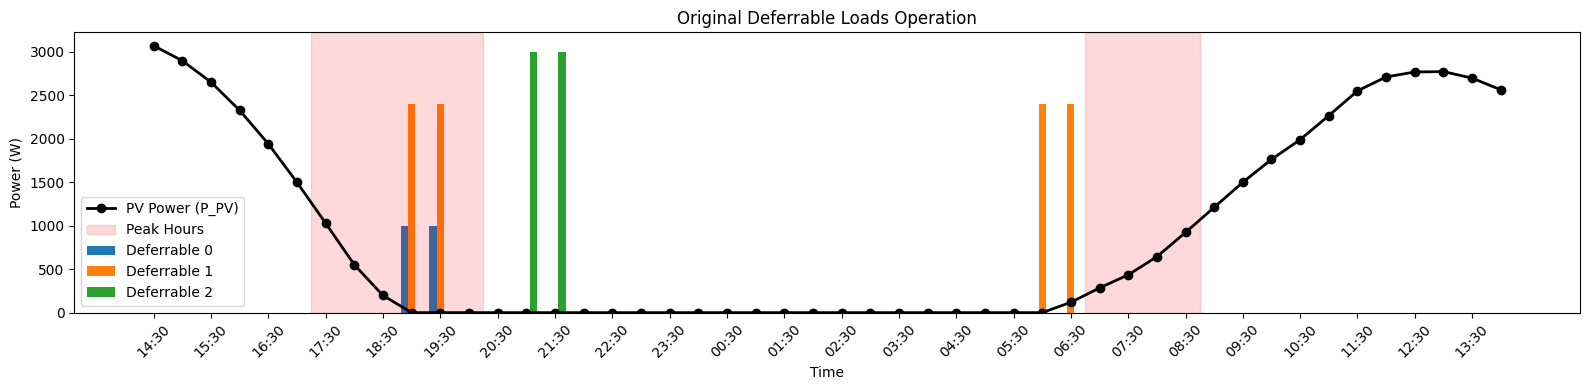

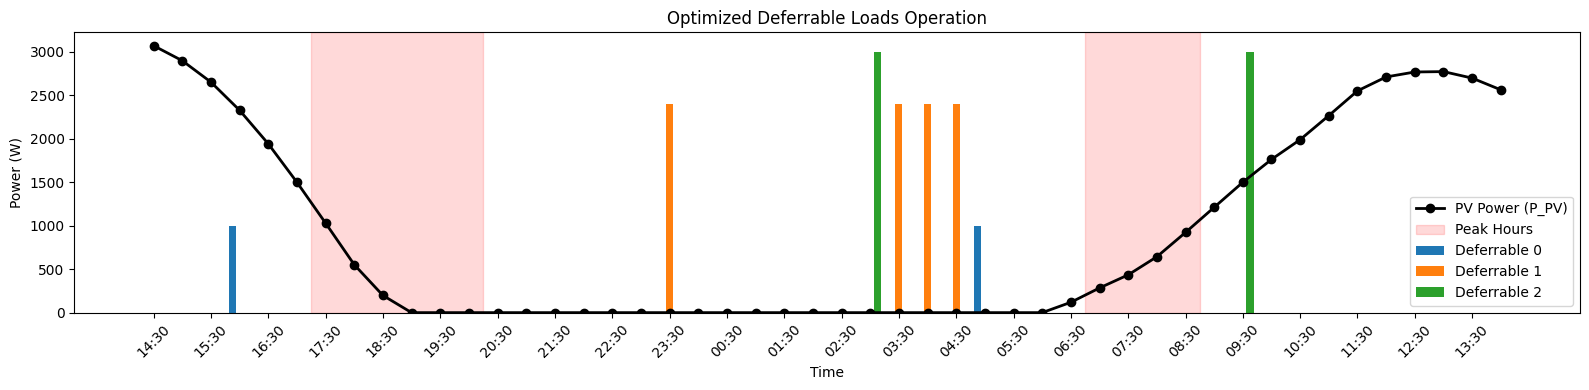

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare time axis
time_axis = pd.to_datetime(df['timestamp'])
time_labels = [t.strftime('%H:%M') for t in time_axis]
x = np.arange(len(time_axis))
bar_width = 0.25

# --- Original schedule ---
plt.figure(figsize=(16, 4))
plt.bar(x - bar_width, df['P_deferrable0'], width=bar_width, label='Deferrable 0')
plt.bar(x, df['P_deferrable1'], width=bar_width, label='Deferrable 1')
plt.bar(x + bar_width, df['P_deferrable2'], width=bar_width, label='Deferrable 2')
# Add P_PV as a line chart
plt.plot(x, df['P_PV'], color='black', marker='o', linestyle='-', linewidth=2, label='PV Power (P_PV)')

# Highlight peak hours: 7–9am and 5:30–8:30pm
for start, end in [(7, 9), (17.5, 20.5)]:
    # Find indices where hour/minute falls in the interval
    indices = [i for i, t in enumerate(time_axis)
               if (t.hour + t.minute/60) >= start and (t.hour + t.minute/60) < end]
    if indices:
        plt.axvspan(indices[0] - 0.5, indices[-1] + 0.5, color='red', alpha=0.15, label='Peak Hours' if start == 7 else None)

plt.title('Original Deferrable Loads Operation')
plt.ylabel('Power (W)')
plt.xlabel('Time')
plt.xticks(ticks=x[::2], labels=[l for i, l in enumerate(time_labels) if i % 2 == 0], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# --- Optimized schedule ---
if 'P_deferrable0' in optimal_df.columns and 'P_deferrable1' in optimal_df.columns and 'P_deferrable2' in optimal_df.columns:
    time_axis_opt = pd.to_datetime(optimal_df['timestamp'])
    time_labels_opt = [t.strftime('%H:%M') for t in time_axis_opt]
    x_opt = np.arange(len(time_axis_opt))
    plt.figure(figsize=(16, 4))
    plt.bar(x_opt - bar_width, optimal_df['P_deferrable0'], width=bar_width, label='Deferrable 0')
    plt.bar(x_opt, optimal_df['P_deferrable1'], width=bar_width, label='Deferrable 1')
    plt.bar(x_opt + bar_width, optimal_df['P_deferrable2'], width=bar_width, label='Deferrable 2')
    # Add P_PV as a line chart
    plt.plot(x, df['P_PV'], color='black', marker='o', linestyle='-', linewidth=2, label='PV Power (P_PV)')

    # Highlight peak hours: 7–9am and 5:30–8:30pm
    for start, end in [(7, 9), (17.5, 20.5)]:
        indices = [i for i, t in enumerate(time_axis_opt)
                   if (t.hour + t.minute/60) >= start and (t.hour + t.minute/60) < end]
        if indices:
            plt.axvspan(indices[0] - 0.5, indices[-1] + 0.5, color='red', alpha=0.15, label='Peak Hours' if start == 7 else None)
    plt.title('Optimized Deferrable Loads Operation')
    plt.ylabel('Power (W)')
    plt.xlabel('Time')
    plt.xticks(ticks=x_opt[::2], labels=[l for i, l in enumerate(time_labels_opt) if i % 2 == 0], rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Optimized schedule columns not found in optimal_df")

In [16]:
# Print out when each deferrable operates after optimization
if all(col in optimal_df.columns for col in ['timestamp', 'P_deferrable0', 'P_deferrable1', 'P_deferrable2']):
    print("Deferrable operation times after optimization:")
    for i, col in enumerate(['P_deferrable0', 'P_deferrable1', 'P_deferrable2']):
        active_times = optimal_df.loc[optimal_df[col] > 0, 'timestamp']
        if not active_times.empty:
            print(f"  {col}:")
            for t in active_times:
                print(f"    {pd.to_datetime(t)}")
        else:
            print(f"  {col}: Not operated")
else:
    print("Required columns for deferrable operation times not found in optimal_df")

Deferrable operation times after optimization:
  P_deferrable0:
    2025-07-14 16:00:00+08:00
    2025-07-15 05:00:00+08:00
  P_deferrable1:
    2025-07-14 23:30:00+08:00
    2025-07-15 03:30:00+08:00
    2025-07-15 04:00:00+08:00
    2025-07-15 04:30:00+08:00
  P_deferrable2:
    2025-07-15 03:00:00+08:00
    2025-07-15 09:30:00+08:00


In [17]:
import plotly.graph_objs as go

labels = ['Savings', 'Remaining Cost']
values = [original_cost - optimal_cost, optimal_cost]
savings_percent = (original_cost - optimal_cost) / original_cost * 100

fig = go.Figure(data=[go.Pie(labels=labels, values=values)])
fig.update_traces(textinfo='label+percent', pull=[0.1, 0], marker=dict(colors=['green', 'orange']))
fig.update_layout(title=f'Cost Savings Percentage: {savings_percent:.2f}%')
fig.show()

In [18]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# optimal_df['timestamp'] = pd.to_datetime(optimal_df['timestamp'])
# optimal_df['hour_decimal'] = optimal_df['timestamp'].dt.hour + optimal_df['timestamp'].dt.minute / 60
# df_corr = pd.DataFrame({
#     'Opt_P_deferrable0': optimal_df['P_deferrable0'],
#     'Opt_P_deferrable1': optimal_df['P_deferrable1'],
#     'P_PV': optimal_df['P_PV'],
#     'P_Load': optimal_df['P_Load'],
#     'time': optimal_df['hour_decimal']
# })

# df_corr.head()
# # Correlation matrix
# corr = df_corr.corr()
# plt.figure(figsize=(7,5))
# sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title('Correlation: Optimal Schedule vs PV, Load, Time')
# plt.show()


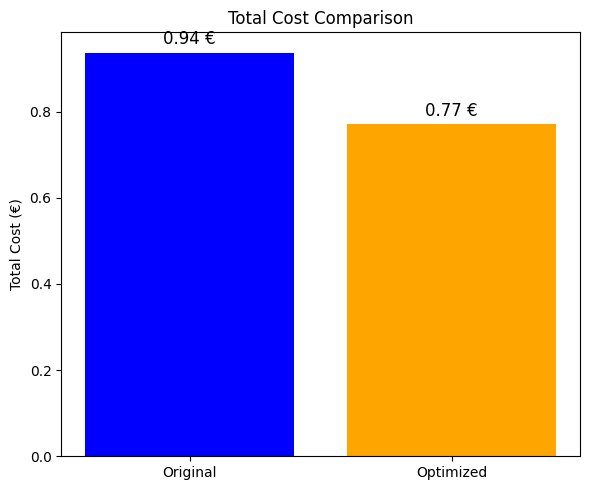

In [19]:
import matplotlib.pyplot as plt

# Bar chart for total cost comparison
costs = [original_cost, optimal_cost]
labels = ['Original', 'Optimized']
colors = ['blue', 'orange']

plt.figure(figsize=(6, 5))
plt.bar(labels, costs, color=colors)
plt.ylabel('Total Cost (€)')
plt.title('Total Cost Comparison')
for i, v in enumerate(costs):
    plt.text(i, v + 0.01 * max(costs), f"{v:.2f} €", ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
# Prepare original deferrable schedule from df
origin_df = df[['timestamp', 'P_deferrable0', 'P_deferrable1', 'P_deferrable2']].copy()
origin_df = origin_df.rename(columns={
    'P_deferrable0': 'Origin_P_deferrable0',
    'P_deferrable1': 'Origin_P_deferrable1',
    'P_deferrable2': 'Origin_P_deferrable2',
    'timestamp': 'time'
})
origin_df['time_of_day'] = pd.to_datetime(origin_df['time']).dt.time

# Prepare optimized deferrable schedule from optimal_df
opt_df = optimal_df[['P_deferrable0', 'P_deferrable1', 'P_deferrable2']].copy()
opt_df = opt_df.rename(columns={
    'P_deferrable0': 'Opt_P_deferrable0',
    'P_deferrable1': 'Opt_P_deferrable1',
    'P_deferrable2': 'Opt_P_deferrable2'
})

# Build comparison DataFrame
comparison_df = origin_df[['time_of_day', 'Origin_P_deferrable0', 'Origin_P_deferrable1','Origin_P_deferrable2']].copy()
comparison_df['Opt_P_deferrable0'] = opt_df['Opt_P_deferrable0'].values
comparison_df['Opt_P_deferrable1'] = opt_df['Opt_P_deferrable1'].values
comparison_df['Opt_P_deferrable2'] = opt_df['Opt_P_deferrable2'].values
comparison_df = comparison_df[
    ['time_of_day', 
     'Origin_P_deferrable0', 'Opt_P_deferrable0', 
     'Origin_P_deferrable1', 'Opt_P_deferrable1',
     'Origin_P_deferrable2', 'Opt_P_deferrable2']
]

comparison_df.head()

,time_of_day,Origin_P_deferrable0,Opt_P_deferrable0,Origin_P_deferrable1,Opt_P_deferrable1,Origin_P_deferrable2,Opt_P_deferrable2
0,14:30:00,0,0.0,0,0.0,0,0.0
1,15:00:00,0,0.0,0,0.0,0,0.0
2,15:30:00,0,0.0,0,0.0,0,0.0
3,16:00:00,0,1000.0,0,0.0,0,0.0
4,16:30:00,0,0.0,0,0.0,0,0.0


In [21]:
import matplotlib.pyplot as plt

# Compute original (naive) cost per 30min slot
original_cost_per_slot =  (0.5 * 0.001 * df['P_grid_pos'] * df['unit_load_cost']  # import cost
    - 0.5 * 0.001 * (-df['P_grid_neg']) * df['unit_prod_price']  # export revenue
)
print("Total original cost:", original_cost_per_slot.sum())
# Get optimized cost per 30min slot
# If cost_fun_selfcons is profit (negative for cost), flip the sign
optimized_cost_per_slot = -optimal_df['cost_fun_profit'] 
print("Total optimal cost:", optimized_cost_per_slot.sum())

Total original cost: 0.9371239752758251
Total optimal cost: 0.77120397854825


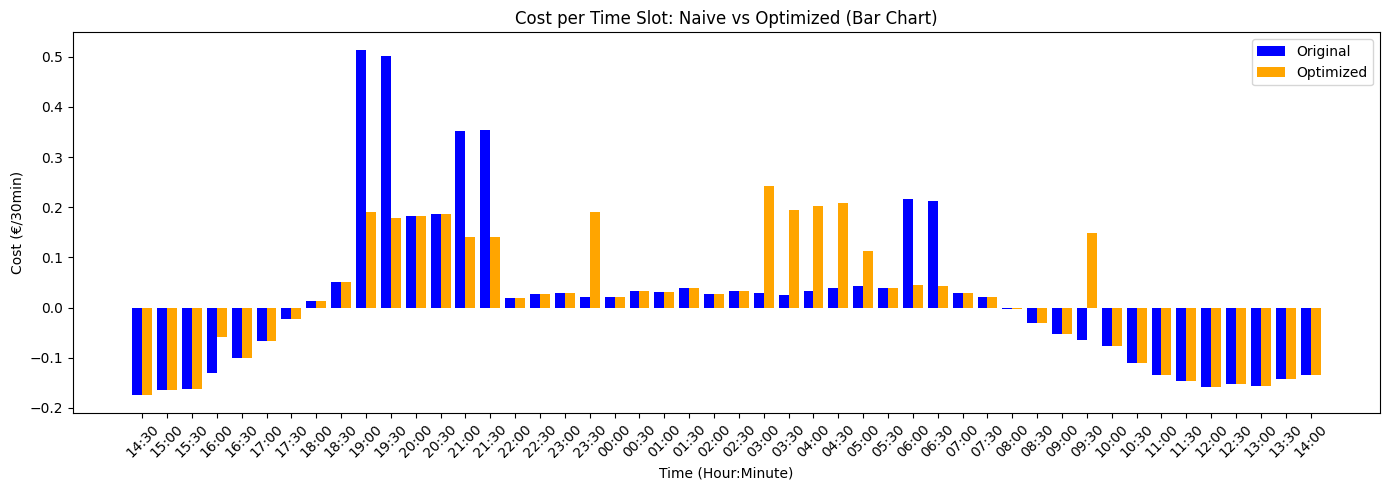

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare time axis (use combined_df['time'] if available, else create a range)
time_axis = pd.to_datetime(df['timestamp'])

# Set up bar width and positions
bar_width = 0.4
x = np.arange(len(time_axis))

plt.figure(figsize=(14, 5))
plt.bar(x - bar_width/2, original_cost_per_slot, width=bar_width, label='Original', color='blue')
if optimized_cost_per_slot is not None:
    plt.bar(x + bar_width/2, optimized_cost_per_slot, width=bar_width, label='Optimized', color='orange')

# Set x-ticks to every 0.5 hour (every slot)
plt.xticks(
    ticks=x[::1],  # every slot (0.5h)
    labels=[t.strftime('%H:%M') for t in time_axis][::1],
    rotation=45
)

plt.xlabel('Time (Hour:Minute)')
plt.ylabel('Cost (€/30min)')
plt.title('Cost per Time Slot: Naive vs Optimized (Bar Chart)')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
import plotly.graph_objs as go

# Prepare time axis (use combined_df['time'] if available, else create a range)
time_axis = pd.to_datetime(df['timestamp'])

fig = go.Figure()

# Bar for Naive (Original)
fig.add_trace(go.Bar(
    x=time_axis,
    y=original_cost_per_slot,
    name='Original',
    marker_color='blue',
    hovertemplate='Time: %{x|%Y-%m-%d %H:%M}<br>Cost: %{y:.4f} €'
))

# Bar for Optimized
if optimized_cost_per_slot is not None:
    fig.add_trace(go.Bar(
        x=time_axis,
        y=optimized_cost_per_slot,
        name='Optimized',
        marker_color='orange',
        hovertemplate='Time: %{x|%Y-%m-%d %H:%M}<br>Cost: %{y:.4f} €'
    ))

fig.update_layout(
    barmode='group',
    title='Cost per Time Slot: Original vs Optimized (Bar Chart)',
    xaxis_title='Time (Hour)',
    yaxis_title='Cost (€/30min)',
    xaxis=dict(
        tickformat='%H:%M',
        tickangle=45,
        rangeslider_visible=True
    ),
    hovermode='x unified'
)


In [24]:
import plotly.graph_objs as go

interval_hours = 0.5  # 30 minutes per row

# Energy per slot in kWh
original_energy_per_slot = df['P_grid'] * interval_hours / 1000
optimized_energy_per_slot = optimal_df['P_grid'] * interval_hours / 1000

time_axis = pd.to_datetime(df['timestamp'])
if 'timestamp' in optimal_df.columns:
    time_axis_opt = pd.to_datetime(optimal_df['timestamp'])
else:
    time_axis_opt = time_axis

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=time_axis,
    y=original_energy_per_slot,
    mode='lines',
    name='Original Energy per Slot (kWh)',
    line=dict(color='blue')
))
fig.add_trace(go.Scatter(
    x=time_axis_opt,
    y=optimized_energy_per_slot,
    mode='lines',
    name='Optimized Energy per Slot (kWh)',
    line=dict(color='orange')
))
fig.update_layout(
    title='Energy Usage per Time Slot: Energy from grid (Original vs Optimized)',
    xaxis_title='Time',
    yaxis_title='Energy per Slot (kWh)',
    hovermode='x unified'
)
fig.show()

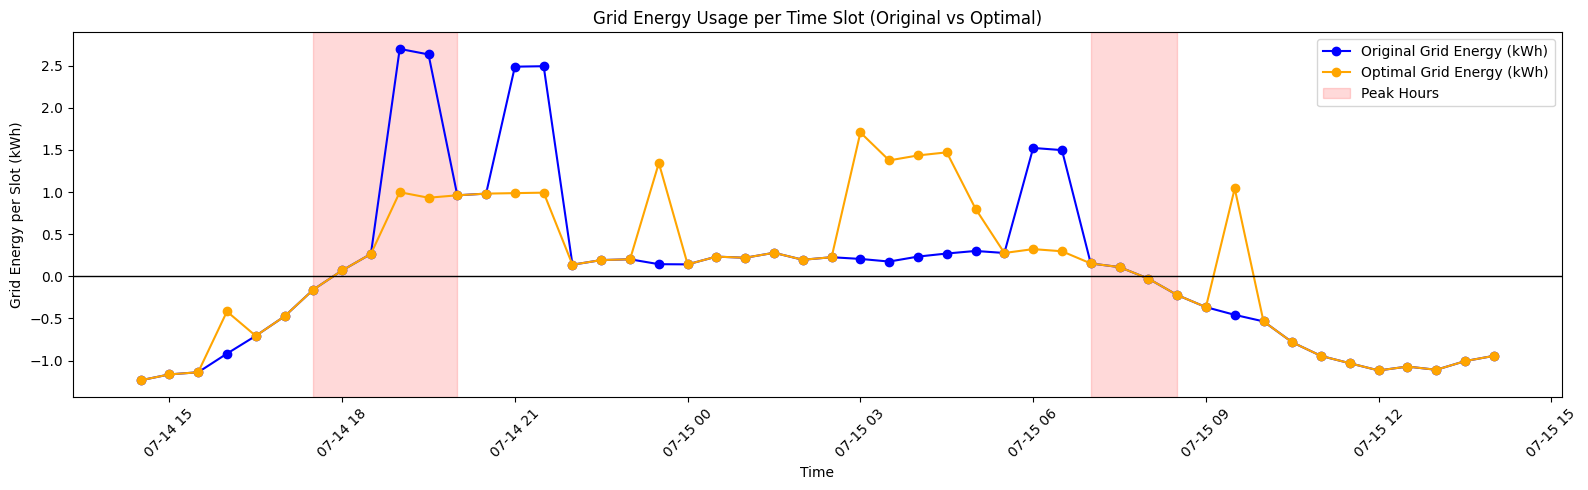

In [25]:
import matplotlib.pyplot as plt
import numpy as np

interval_hours = 0.5  # 30 minutes per row

# Energy per slot in kWh (grid usage)
original_grid_energy = df['P_grid'] * interval_hours / 1000
optimal_grid_energy = optimal_df['P_grid'] * interval_hours / 1000

# Prepare time axes
time_axis = pd.to_datetime(df['timestamp'])
time_labels = [t.strftime('%H:%M') for t in time_axis]

plt.figure(figsize=(16, 5))
plt.plot(time_axis, original_grid_energy, label='Original Grid Energy (kWh)', color='blue', marker='o')
plt.plot(time_axis_opt, optimal_grid_energy, label='Optimal Grid Energy (kWh)', color='orange', marker='o')

# Highlight peak hours: 7–9am and 5:30–8:30pm
for start, end in [(7, 9), (17.5, 20.5)]:
    indices = [i for i, t in enumerate(time_axis)
               if (t.hour + t.minute/60) >= start and (t.hour + t.minute/60) < end]
    if indices:
        plt.axvspan(time_axis[indices[0]], time_axis[indices[-1]], color='red', alpha=0.15, label='Peak Hours' if start == 7 else None)

plt.axhline(0, color='black', linewidth=1)
plt.title('Grid Energy Usage per Time Slot (Original vs Optimal)')
plt.ylabel('Grid Energy per Slot (kWh)')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

In [26]:
import plotly.graph_objs as go
import numpy as np

interval_hours = 0.5  # 30 minutes per row

# Grid import (kWh)
grid_import = df['P_grid_pos'] * interval_hours / 1000

# Grid export (kWh, positive values)
grid_export = df['P_grid_neg'] * interval_hours / 1000

# Solar used for load/deferrables (kWh)
# The actual solar used is the minimum of available PV and the total load minus grid import
total_load = df['P_Load'] + df['P_deferrable0'] + df['P_deferrable1'] + df['P_deferrable2']
solar_used = (total_load - df['P_grid_pos']).clip(lower=0)
solar_used = np.minimum(solar_used, df['P_PV']) * interval_hours / 1000

# Prepare time axis
time_axis = pd.to_datetime(df['timestamp'])

fig = go.Figure()
fig.add_trace(go.Bar(
    x=time_axis,
    y=grid_import,
    name='Grid Consumption (kWh)',
    marker_color='orange'
))
fig.add_trace(go.Bar(
    x=time_axis,
    y=solar_used,
    name='Solar Consumption (kWh)',
    marker_color='green'
))
fig.add_trace(go.Bar(
    x=time_axis,
    y=grid_export,
    name='Export to Grid (kWh)',
    marker_color='blue'
))

fig.update_layout(
    barmode='stack',
    title='Original Energy Usage per Time Slot',
    xaxis_title='Time',
    yaxis_title='Energy (kWh)',
    hovermode='x unified'
)
fig.show()

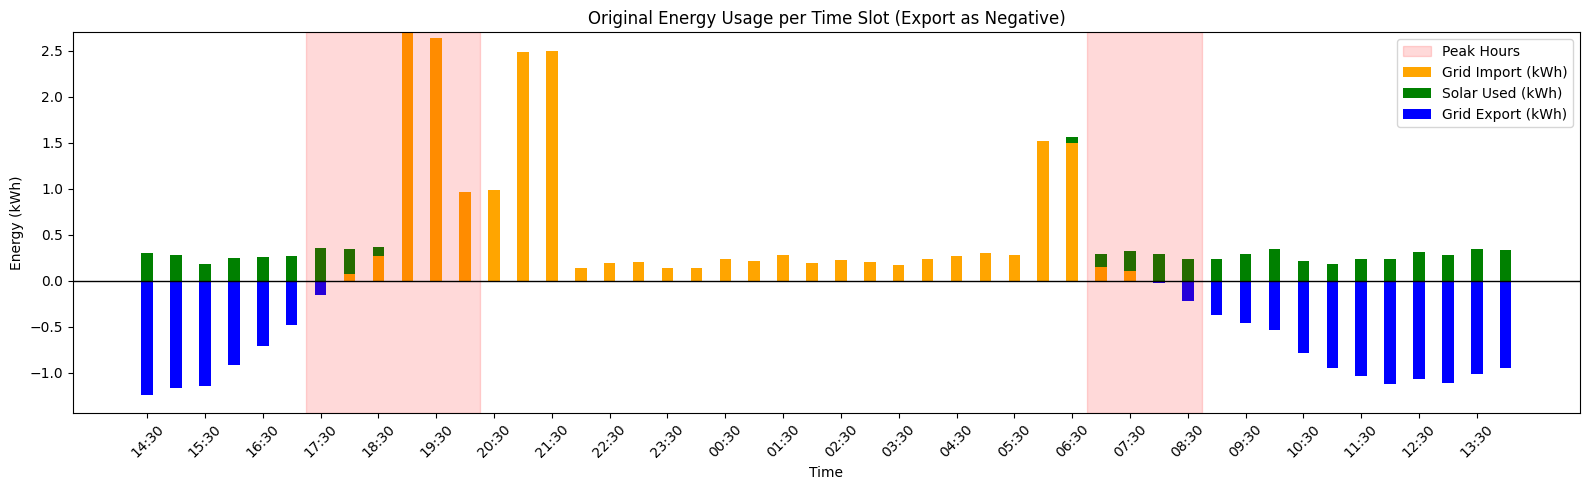

In [27]:
import matplotlib.pyplot as plt
import numpy as np

interval_hours = 0.5  # 30 minutes per row

# Prepare time axis
time_axis = pd.to_datetime(df['timestamp'])
time_labels = [t.strftime('%H:%M') for t in time_axis]
x = np.arange(len(time_axis))
bar_width = 0.4

# Grid import (kWh, positive)
grid_import = df['P_grid_pos'] * interval_hours / 1000
# Grid export (kWh, negative for export)
grid_export = df['P_grid_neg'] * interval_hours / 1000  # negative values

# Solar used for load/deferrables (kWh)
total_load = df['P_Load'] + df['P_deferrable0'] + df['P_deferrable1'] + df['P_deferrable2']
solar_used = (total_load - df['P_grid_pos']).clip(lower=0)
solar_used = np.minimum(solar_used, df['P_PV']) * interval_hours / 1000

plt.figure(figsize=(16, 5))
plt.bar(x, grid_import, width=bar_width, label='Grid Import (kWh)', color='orange')
plt.bar(x, solar_used, width=bar_width, bottom=grid_import, label='Solar Used (kWh)', color='green')
plt.bar(x, grid_export, width=bar_width, label='Grid Export (kWh)', color='blue')  # negative values

# Highlight peak hours: 7–9am and 5:30–8:30pm
for start, end in [(7, 9), (17.5, 20.5)]:
    indices = [i for i, t in enumerate(time_axis)
               if (t.hour + t.minute/60) >= start and (t.hour + t.minute/60) < end]
    if indices:
        plt.axvspan(indices[0] - 0.5, indices[-1] + 0.5, color='red', alpha=0.15, label='Peak Hours' if start == 7 else None)

plt.axhline(0, color='black', linewidth=1)
plt.title('Original Energy Usage per Time Slot (Export as Negative)')
plt.ylabel('Energy (kWh)')
plt.xlabel('Time')
plt.xticks(ticks=x[::2], labels=[l for i, l in enumerate(time_labels) if i % 2 == 0], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

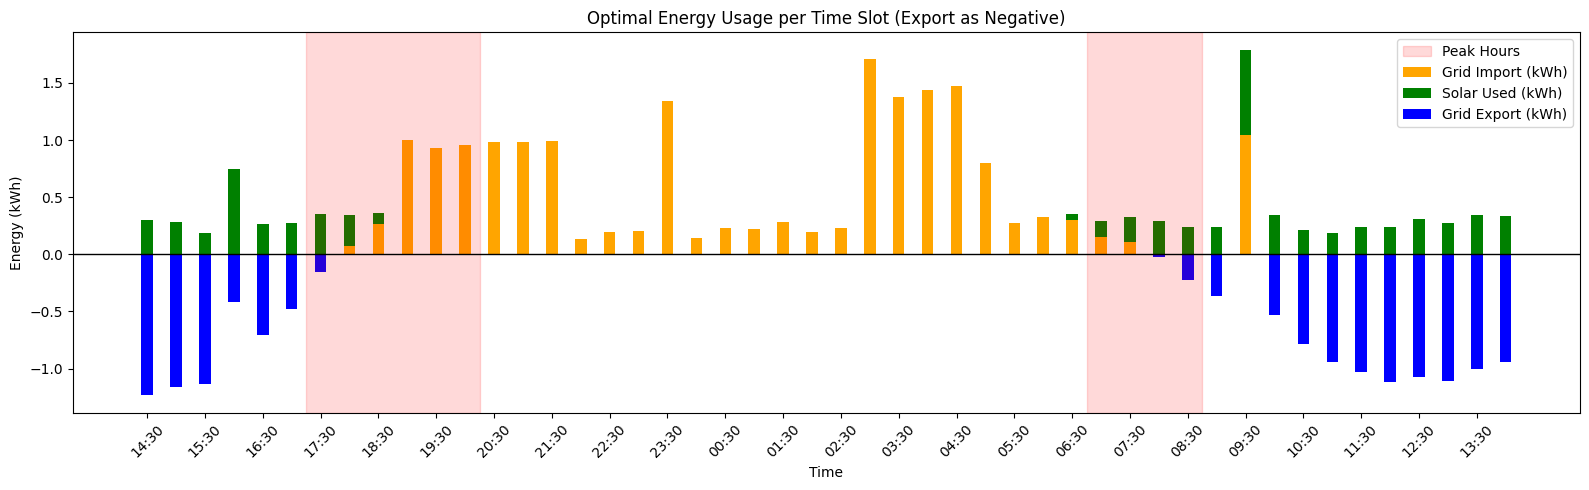

In [28]:
import matplotlib.pyplot as plt
import numpy as np

interval_hours = 0.5  # 30 minutes per row

# Prepare time axis
time_axis = pd.to_datetime(optimal_df['timestamp'])
time_labels = [t.strftime('%H:%M') for t in time_axis]
x = np.arange(len(time_axis))
bar_width = 0.4

# Grid import (kWh, positive)
grid_import = optimal_df['P_grid_pos'] * interval_hours / 1000
# Grid export (kWh, negative for export)
grid_export = optimal_df['P_grid_neg'] * interval_hours / 1000  # negative values

# Solar used for load/deferrables (kWh)
total_load = optimal_df['P_Load'] + optimal_df['P_deferrable0'] + optimal_df['P_deferrable1'] + optimal_df['P_deferrable2']
solar_used = (total_load - optimal_df['P_grid_pos']).clip(lower=0)
solar_used = np.minimum(solar_used, optimal_df['P_PV']) * interval_hours / 1000

plt.figure(figsize=(16, 5))
plt.bar(x, grid_import, width=bar_width, label='Grid Import (kWh)', color='orange')
plt.bar(x, solar_used, width=bar_width, bottom=grid_import, label='Solar Used (kWh)', color='green')
plt.bar(x, grid_export, width=bar_width, label='Grid Export (kWh)', color='blue')  # negative values

# Highlight peak hours: 7–9am and 5:30–8:30pm
for start, end in [(7, 9), (17.5, 20.5)]:
    indices = [i for i, t in enumerate(time_axis)
               if (t.hour + t.minute/60) >= start and (t.hour + t.minute/60) < end]
    if indices:
        plt.axvspan(indices[0] - 0.5, indices[-1] + 0.5, color='red', alpha=0.15, label='Peak Hours' if start == 7 else None)

plt.axhline(0, color='black', linewidth=1)
plt.title('Optimal Energy Usage per Time Slot (Export as Negative)')
plt.ylabel('Energy (kWh)')
plt.xlabel('Time')
plt.xticks(ticks=x[::2], labels=[l for i, l in enumerate(time_labels) if i % 2 == 0], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
import plotly.graph_objs as go
import numpy as np

interval_hours = 0.5  # 30 minutes per row

# Grid import (kWh)
grid_import_opt = optimal_df['P_grid_pos'] * interval_hours / 1000

# Grid export (kWh, positive values)
grid_export_opt = optimal_df['P_grid_neg'] * interval_hours / 1000

# Solar used for load/deferrables (kWh)
total_load_opt = optimal_df['P_Load'] + optimal_df['P_deferrable0'] + optimal_df['P_deferrable1']
solar_used_opt = (total_load_opt - optimal_df['P_grid_pos']).clip(lower=0)
solar_used_opt = np.minimum(solar_used_opt, optimal_df['P_PV']) * interval_hours / 1000

# Prepare time axis
if 'timestamp' in optimal_df.columns:
    time_axis_opt = pd.to_datetime(optimal_df['timestamp'])
else:
    time_axis_opt = np.arange(len(optimal_df))

fig = go.Figure()
fig.add_trace(go.Bar(
    x=time_axis_opt,
    y=grid_import_opt,
    name='Grid Consumption (kWh)',
    marker_color='orange'
))
fig.add_trace(go.Bar(
    x=time_axis_opt,
    y=solar_used_opt,
    name='Solar Consumption (kWh)',
    marker_color='green'
))
fig.add_trace(go.Bar(
    x=time_axis_opt,
    y=grid_export_opt,
    name='Export to Grid (kWh)',
    marker_color='blue'
))

fig.update_layout(
    barmode='stack',
    title='Optimized Energy Usage per Time Slot',
    xaxis_title='Time',
    yaxis_title='Energy (kWh)',
    hovermode='x unified'
)
fig.show()

In [30]:
import pandas as pd
import plotly.graph_objs as go
import numpy as np

interval_hours = 0.5  # 30 minutes per row

# --- Original ---
total_load = (df['P_Load'] + df['P_deferrable0'] + df['P_deferrable1']) * interval_hours / 1000
solar_used = (total_load - df['P_grid_pos']).clip(lower=0)
solar_used = np.minimum(solar_used, df['P_PV'] * interval_hours / 1000)
total_solar_used = solar_used.sum()
total_load_sum = total_load.sum()
self_sufficiency_original = (total_solar_used / total_load_sum) * 100 if total_load_sum != 0 else 0

# --- Optimal ---
total_load_opt = (optimal_df['P_Load'] + optimal_df['P_deferrable0'] + optimal_df['P_deferrable1']) * interval_hours / 1000
solar_used_opt = (total_load_opt - optimal_df['P_grid_pos'] * interval_hours / 1000).clip(lower=0)
solar_used_opt = np.minimum(solar_used_opt, optimal_df['P_PV'] * interval_hours / 1000)
total_solar_used_opt = solar_used_opt.sum()
total_load_sum_opt = total_load_opt.sum()
self_sufficiency_optimal = (total_solar_used_opt / total_load_sum_opt) * 100 if total_load_sum_opt != 0 else 0

# --- Table ---
improvement = self_sufficiency_optimal - self_sufficiency_original
table = pd.DataFrame({
    'Scenario': ['Original', 'Optimized', 'Improvement'],
    'Self-Sufficiency (%)': [self_sufficiency_original, self_sufficiency_optimal, improvement]
})
print(table)

# --- Pie charts ---
labels = ['Solar Used for Load', 'Grid Used for Load']
values_original = [total_solar_used, total_load_sum - total_solar_used]
values_optimal = [total_solar_used_opt, total_load_sum_opt - total_solar_used_opt]

fig1 = go.Figure(data=[go.Pie(labels=labels, values=values_original, hole=0.4)])
fig1.update_layout(title='Original Self-Sufficiency', annotations=[dict(text='Original', x=0.5, y=0.5, font_size=16, showarrow=False)])

fig2 = go.Figure(data=[go.Pie(labels=labels, values=values_optimal, hole=0.4)])
fig2.update_layout(title='Optimized Self-Sufficiency', annotations=[dict(text='Optimized', x=0.5, y=0.5, font_size=16, showarrow=False)])

fig1.show()
fig2.show()

      Scenario  Self-Sufficiency (%)
0     Original             24.207215
1    Optimized             28.644124
2  Improvement              4.436909


In [31]:
import pandas as pd
import plotly.graph_objs as go

interval_hours = 0.5  # 30 minutes per row

# Total grid energy consumption (kWh)
total_grid_original = (df['P_grid_pos'] * interval_hours / 1000).sum()
total_grid_optimal = (optimal_df['P_grid_pos'] * interval_hours / 1000).sum()
energy_saving = total_grid_original - total_grid_optimal
saving_percent = (energy_saving / total_grid_original) * 100 if total_grid_original != 0 else 0

# Table
energy_table = pd.DataFrame({
    'Scenario': ['Original', 'Optimized', 'Saving'],
    'Grid Energy (kWh)': [total_grid_original, total_grid_optimal, energy_saving],
    'Saving (%)': [None, None, saving_percent]
})
print(energy_table)

# Pie chart
labels = ['Original Grid Consumption', 'Saved Energy']
values = [total_grid_optimal, energy_saving]
fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=0.4)])
fig.update_layout(
    title='Grid Energy Consumption and Savings',
    annotations=[dict(text='Grid', x=0.5, y=0.5, font_size=20, showarrow=False)]
)
fig.show()

    Scenario  Grid Energy (kWh)  Saving (%)
0   Original          19.302541         NaN
1  Optimized          18.345264         NaN
2     Saving           0.957277    4.959333
